# Figure 14 Reproduction (Subgrid Onset Variability)

This notebook reproduces Fig.14 using IMD rainfall data from **1901-2024**.

- **Panel (a)**: 1-degree subgrid variability relative to its parent 4-degree onset date
- **Panel (b)**: 0.25-degree subgrid variability relative to its parent 4-degree onset date

Method used here follows the figure note: 4-degree onset dates are taken from regridded 1-degree IMD data (available in `imd_rainfall_data/4p0`).

## 1) Imports

In [1]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.ticker import FuncFormatter

from monsoonbench.metrics.base import OnsetMetricsBase

## 2) Paths and Run Configuration

In [2]:
# Project root (run notebook from repository root or keep this relative setting)

cwd = Path.cwd()
repo_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "pyproject.toml").exists()), cwd
)
print(repo_root)
data_dir = repo_root / "data"
out_dir = repo_root / "examples" / "demo_notebooks" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

imd_1deg_dir = data_dir / "imd_rainfall_data" / "1p0"
imd_025deg_dir_raw = data_dir / "imd_rainfall_data" / "0p25"
imd_025deg_dir_cdo = data_dir / "imd_rainfall_data" / "0p25_cdo_6625"
imd_4deg_dir = data_dir / "imd_rainfall_data" / "4p0"

# Switch: use CDO-regridded rainfall (66.625/6.625-centered grid)
use_cdo_025_rainfall = True
imd_025deg_dir = imd_025deg_dir_cdo if use_cdo_025_rainfall else imd_025deg_dir_raw

thres_1deg_file = data_dir / "imd_onset_threshold" / "mwset1x1.nc4"
thres_4deg_file = data_dir / "imd_onset_threshold" / "mwset4x4.nc4"
thres_025deg_candidates = [
    data_dir / "imd_onset_threshold" / "mwset0p25x0p25.nc4",
    data_dir / "imd_onset_threshold" / "mwset0p25.nc4",
    data_dir / "imd_onset_threshold" / "mwset0.25.nc4",
    data_dir / "imd_onset_threshold" / "mwset025.nc4",
]
shp_file = data_dir / "ind_map_shpfile" / "india_shapefile.shp"

mode_tag = "cdo025" if use_cdo_025_rainfall else "raw025"
cache_nc = (
    out_dir / f"figure14_subgrid_variability_native4deg_author025grid_{mode_tag}.nc"
)
fig_png = out_dir / f"figure14_subgrid_variability_{mode_tag}.png"

# Set to a short list while debugging (e.g., [2019, 2020])
debug_years = None
years = debug_years if debug_years is not None else list(range(1901, 2025))

# Whether to recompute from raw files even if cache exists
force_recompute = True

# MOK=True means onset search starts after June 2nd (consistent with repository default analyses)
mok = True

thres_025deg_file = next((x for x in thres_025deg_candidates if x.exists()), None)
if thres_025deg_file is None:
    raise FileNotFoundError(
        "Native 0.25-degree threshold file not found. Expected one of: "
        + ", ".join(str(x.name) for x in thres_025deg_candidates)
    )
if not imd_025deg_dir.exists():
    raise FileNotFoundError(f"0.25 rainfall directory not found: {imd_025deg_dir}")

# Key switch: force both rainfall and threshold onto author 0.25 grid (66.625/6.625)
use_author_025_grid = True

print(data_dir)
print("Years:", years[0], "to", years[-1], f"(n={len(years)})")
print("Cache:", cache_nc)
print("Figure:", fig_png)
print("0.25 threshold:", thres_025deg_file)
print("0.25 rainfall source:", imd_025deg_dir)
print("author 0.25-grid forcing enabled:", use_author_025_grid)

c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench
c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data
Years: 1901 to 2024 (n=124)
Cache: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\figure14_subgrid_variability_native4deg_author025grid.nc
Figure: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\figure14_subgrid_variability.png
0.25 threshold: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_onset_threshold\mwset0p25x0p25.nc4
author 0.25-grid forcing enabled: True


## 2b) Verify Selected 0.25 Rainfall Grid (Optional)


In [3]:
def _standardize_rainfall_dims(rain: xr.DataArray) -> xr.DataArray:
    """Ensure rainfall data uses ('time', 'lat', 'lon') in this order."""
    rename_map = {}
    if "TIME" in rain.dims:
        rename_map["TIME"] = "time"
    if "LATITUDE" in rain.dims:
        rename_map["LATITUDE"] = "lat"
    if "LONGITUDE" in rain.dims:
        rename_map["LONGITUDE"] = "lon"
    if rename_map:
        rain = rain.rename(rename_map)
    return rain.transpose("time", "lat", "lon")


def _load_imd(year: int, folder: Path) -> xr.DataArray:
    rain = OnsetMetricsBase.load_imd_rainfall(year, str(folder))
    return _standardize_rainfall_dims(rain)


def _load_threshold(path: Path) -> xr.DataArray:
    """Load MWmean threshold and fix possible lat/lon swapped coordinate labels."""
    th = xr.open_dataset(path)["MWmean"]
    rename_map = {}
    if "LATITUDE" in th.dims:
        rename_map["LATITUDE"] = "lat"
    if "LONGITUDE" in th.dims:
        rename_map["LONGITUDE"] = "lon"
    if rename_map:
        th = th.rename(rename_map)

    if set(th.dims) == {"lat", "lon"}:
        th = th.transpose("lat", "lon")

    lat_vals = th["lat"].values
    lon_vals = th["lon"].values
    if np.nanmax(lat_vals) > 60 and np.nanmax(lon_vals) < 50:
        th = (
            th.rename({"lat": "tmp", "lon": "lat"})
            .rename({"tmp": "lon"})
            .transpose("lat", "lon")
        )

    return th


def _note_native_4deg():
    """Use native 4-degree IMD rainfall (conservative remapping precomputed)."""
    return


AUTHOR_025_XFIRST = 66.625
AUTHOR_025_YFIRST = 6.625
AUTHOR_025_INC = 0.25
AUTHOR_025_XSIZE = 135
AUTHOR_025_YSIZE = 129


def _author_025_coords() -> dict:
    lon = AUTHOR_025_XFIRST + AUTHOR_025_INC * np.arange(AUTHOR_025_XSIZE)
    lat = AUTHOR_025_YFIRST + AUTHOR_025_INC * np.arange(AUTHOR_025_YSIZE)
    return {
        "lat": xr.DataArray(lat, dims=["lat"]),
        "lon": xr.DataArray(lon, dims=["lon"]),
    }


def _is_same_grid_2d(
    da: xr.DataArray,
    target_lat: xr.DataArray,
    target_lon: xr.DataArray,
    tol: float = 1e-9,
) -> bool:
    if "lat" not in da.coords or "lon" not in da.coords:
        return False
    if da.sizes.get("lat") != target_lat.size or da.sizes.get("lon") != target_lon.size:
        return False
    return np.allclose(da["lat"].values, target_lat.values, atol=tol) and np.allclose(
        da["lon"].values, target_lon.values, atol=tol
    )


def _interp_to_grid_2d(
    da: xr.DataArray,
    target_lat: xr.DataArray,
    target_lon: xr.DataArray,
    label: str = "",
) -> xr.DataArray:
    """Interpolate to target grid with linear first, then nearest for edge fill."""
    out_lin = da.interp(lat=target_lat, lon=target_lon, method="linear")
    if np.isnan(out_lin.values).any():
        out_nn = da.interp(lat=target_lat, lon=target_lon, method="nearest")
        out_lin = out_lin.where(np.isfinite(out_lin), out_nn)
    if label:
        print(
            f"  Regridded {label} -> author 0.25 grid ({float(target_lon.values[0]):.3f}, {float(target_lat.values[0]):.3f})"
        )
    return out_lin


def _force_author_025_grid(
    rain_025: xr.DataArray, thres_025: xr.DataArray, year: int | None = None
) -> tuple[xr.DataArray, xr.DataArray]:
    """Force rainfall/threshold to the same author grid to avoid 0.125-degree offset artifacts."""
    tgt = _author_025_coords()
    tgt_lat, tgt_lon = tgt["lat"], tgt["lon"]

    rain_out = rain_025
    if not _is_same_grid_2d(rain_out, tgt_lat, tgt_lon):
        rain_out = _interp_to_grid_2d(
            rain_out,
            tgt_lat,
            tgt_lon,
            label=f"0.25 rainfall {year}" if year else "0.25 rainfall",
        )

    thres_out = thres_025
    if not _is_same_grid_2d(thres_out, tgt_lat, tgt_lon):
        thres_out = _interp_to_grid_2d(
            thres_out, tgt_lat, tgt_lon, label="0.25 threshold"
        )

    # Final strict coordinate identity before onset detection
    rain_out = rain_out.assign_coords(lat=thres_out["lat"], lon=thres_out["lon"])
    return rain_out, thres_out


def _abs_day_diff(
    sub_onset: xr.DataArray, coarse_onset_on_sub: xr.DataArray
) -> xr.DataArray:
    """Compute absolute day difference between two onset-date maps (datetime arrays)."""
    sub_vals = sub_onset.values
    coarse_vals = coarse_onset_on_sub.values
    valid = (~np.isnat(sub_vals)) & (~np.isnat(coarse_vals))

    out = np.full(sub_vals.shape, np.nan, dtype=float)
    out[valid] = np.abs((sub_vals[valid] - coarse_vals[valid]) / np.timedelta64(1, "D"))

    return xr.DataArray(
        out, coords=sub_onset.coords, dims=sub_onset.dims, name="abs_day_diff"
    )


def _mean_abs_diff_within_parent_4deg(
    sub_onset: xr.DataArray, onset_4deg: xr.DataArray
) -> xr.DataArray:
    """For each 4-degree parent cell, compute mean |subgrid onset - parent onset| in days."""
    out = np.full(onset_4deg.shape, np.nan, dtype=float)

    for i, lat4 in enumerate(onset_4deg.lat.values):
        for j, lon4 in enumerate(onset_4deg.lon.values):
            parent_onset = onset_4deg.values[i, j]
            if np.isnat(parent_onset):
                continue

            lat_lo, lat_hi = lat4 - 2.0, lat4 + 2.0
            lon_lo, lon_hi = lon4 - 2.0, lon4 + 2.0

            sub = sub_onset.where(
                (sub_onset.lat >= lat_lo)
                & (sub_onset.lat < lat_hi)
                & (sub_onset.lon >= lon_lo)
                & (sub_onset.lon < lon_hi),
                drop=True,
            )
            vals = sub.values.ravel()
            valid = ~np.isnat(vals)
            if not valid.any():
                continue

            out[i, j] = np.abs(
                (vals[valid] - parent_onset) / np.timedelta64(1, "D")
            ).mean()

    return xr.DataArray(
        out, coords=onset_4deg.coords, dims=onset_4deg.dims, name="mean_abs_day_diff"
    )


def _degree_formatter_lon(x, pos):
    return f"{int(x)} degE"


def _degree_formatter_lat(x, pos):
    return f"{int(x)} degN"


def _draw_cmz_grid(ax, edgecolor="black", linewidth=1.0, **kwargs):
    """Draw CMZ 4-degree box overlay similar to the paper figure."""
    lon_lines = [70, 74, 78, 82, 86]
    lat_lines = [18, 22, 26, 30]

    for lon in lon_lines:
        ax.plot([lon, lon], [18, 30], color=edgecolor, linewidth=linewidth, zorder=5)
    for lat in lat_lines:
        ax.plot([70, 86], [lat, lat], color=edgecolor, linewidth=linewidth, zorder=5)

## 3) Helpers

In [ ]:
sample_files = sorted(imd_025deg_dir.glob("*.nc"))
print("Selected folder:", imd_025deg_dir)
print("File count:", len(sample_files))
if sample_files:
    da = _standardize_rainfall_dims(
        xr.open_dataset(sample_files[0])[
            list(xr.open_dataset(sample_files[0]).data_vars)[0]
        ]
    )
    print("Sample file:", sample_files[0].name)
    print(
        "lat first/last/step:",
        float(da.lat.values[0]),
        float(da.lat.values[-1]),
        float(np.median(np.diff(da.lat.values))),
    )
    print(
        "lon first/last/step:",
        float(da.lon.values[0]),
        float(da.lon.values[-1]),
        float(np.median(np.diff(da.lon.values))),
    )

## 4) Compute Mean Subgrid Variability Maps (1901-2024)

In [4]:
if cache_nc.exists() and not force_recompute:
    print("Loading cached results from", cache_nc)
    ds_fig14 = xr.open_dataset(cache_nc)
    cache_ok = (
        "panel_a_1deg" in ds_fig14.data_vars
        and "panel_b_025deg" in ds_fig14.data_vars
        and (
            "lat1" in ds_fig14["panel_a_1deg"].dims
            and "lon1" in ds_fig14["panel_a_1deg"].dims
        )
    )
    if not cache_ok:
        print("Cache format is old/incompatible. Recomputing...")
        force_recompute = True

if (not cache_nc.exists()) or force_recompute:
    thres_1deg = _load_threshold(thres_1deg_file)
    thres_4deg = _load_threshold(thres_4deg_file)
    thres_025deg_native = _load_threshold(thres_025deg_file)

    yearly_a_1deg = []
    yearly_b_025deg = []

    for idx, year in enumerate(years, start=1):
        print(f"[{idx}/{len(years)}] Processing year {year} ...")

        rain_1deg = _load_imd(year, imd_1deg_dir)
        rain_025deg = _load_imd(year, imd_025deg_dir)
        rain_4deg = _load_imd(year, imd_4deg_dir)

        onset_1deg = OnsetMetricsBase.detect_observed_onset(
            rain_1deg, thres_1deg, year, mok=mok
        )
        onset_4deg = OnsetMetricsBase.detect_observed_onset(
            rain_4deg, thres_4deg, year, mok=mok
        )

        onset_4_on_1 = onset_4deg.sel(
            lat=onset_1deg.lat, lon=onset_1deg.lon, method="nearest"
        )
        var_a_1deg = _abs_day_diff(onset_1deg, onset_4_on_1)

        if use_author_025_grid:
            rain_025deg_this_year, thres_025deg_this_year = _force_author_025_grid(
                rain_025deg, thres_025deg_native, year=year
            )
        else:
            rain_025deg_this_year, thres_025deg_this_year = (
                rain_025deg,
                thres_025deg_native,
            )

        onset_025deg = OnsetMetricsBase.detect_observed_onset(
            rain_025deg_this_year, thres_025deg_this_year, year, mok=mok
        )
        onset_4_on_025 = onset_4deg.sel(
            lat=onset_025deg.lat, lon=onset_025deg.lon, method="nearest"
        )
        var_b_025deg = _abs_day_diff(onset_025deg, onset_4_on_025)

        yearly_a_1deg.append(var_a_1deg.expand_dims(year=[year]))
        yearly_b_025deg.append(var_b_025deg.expand_dims(year=[year]))

    panel_a = (
        xr.concat(yearly_a_1deg, dim="year")
        .mean("year", skipna=True)
        .rename("panel_a_1deg")
    )
    panel_b = (
        xr.concat(yearly_b_025deg, dim="year")
        .mean("year", skipna=True)
        .rename("panel_b_025deg")
    )

    panel_a = panel_a.rename({"lat": "lat1", "lon": "lon1"})
    panel_b = panel_b.rename({"lat": "lat025", "lon": "lon025"})

    ds_fig14 = xr.Dataset(
        {
            "panel_a_1deg": panel_a,
            "panel_b_025deg": panel_b,
        }
    )
    ds_fig14.attrs["years"] = f"{years[0]}-{years[-1]}"
    ds_fig14.attrs["mok"] = str(mok)
    ds_fig14.to_netcdf(cache_nc)
    print("Saved cache to", cache_nc)

print(ds_fig14)

[1/124] Processing year 1901 ...
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\1p0\data_1901.nc
Renamed dimensions: {'LATITUDE': 'lat', 'LONGITUDE': 'lon', 'TIME': 'time'}
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\0p25\1901.nc
Renamed dimensions: {'TIME': 'time'}
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
  Regridded 0.25 threshold -> author 0.25 grid (66.625, 6.625)
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
[2/124] Processing year 1902 ...
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\

## 5) Plot Figure 14

Saved figure to c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\figure14_subgrid_variability.png


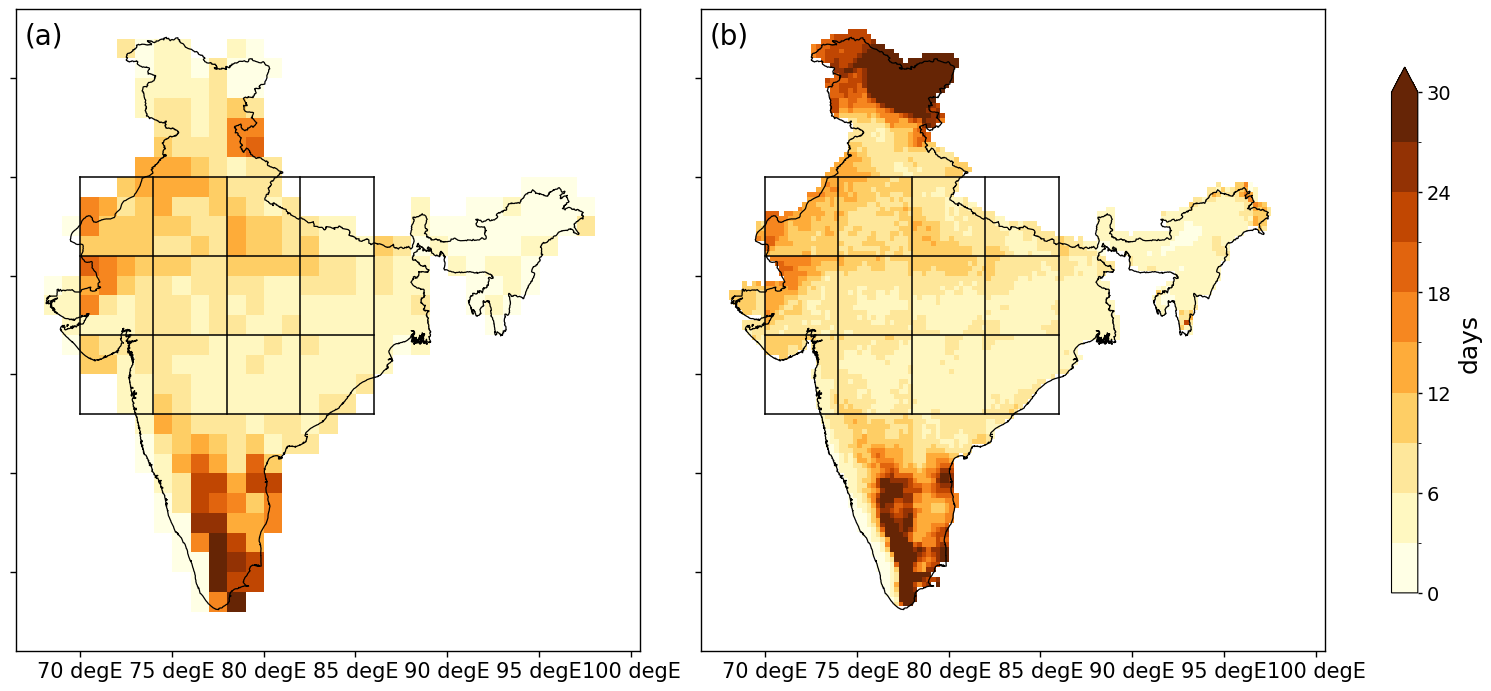

In [5]:
india_boundaries = OnsetMetricsBase.get_india_outline(str(shp_file))

panel_a = ds_fig14["panel_a_1deg"]
panel_b = ds_fig14["panel_b_025deg"]

# Author-like visual style
map_lw = 0.9
grid_lw = 1.1
tick_length = 4
tick_width = 1.0
panel_linewidth = 1.0

# Discrete color bins (as in reference figure)
bounds = np.arange(0, 33, 3)  # 0..30, 10 bins
cmap = plt.get_cmap("YlOrBr", len(bounds) - 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N, clip=True)

# Larger typography to match reference
tick_fs = 15
panel_fs = 20
cbar_label_fs = 18
cbar_tick_fs = 14

fig, axes = plt.subplots(
    1, 2, figsize=(14.8, 6.8), sharex=True, sharey=True, constrained_layout=True
)
fig.patch.set_facecolor("white")

res_a_lat = float(np.median(np.diff(panel_a["lat1"].values)))
res_a_lon = float(np.median(np.diff(panel_a["lon1"].values)))
extent_a = [
    float(panel_a["lon1"].min() - res_a_lon / 2),
    float(panel_a["lon1"].max() + res_a_lon / 2),
    float(panel_a["lat1"].min() - res_a_lat / 2),
    float(panel_a["lat1"].max() + res_a_lat / 2),
]

res_b_lat = float(np.median(np.diff(panel_b["lat025"].values)))
res_b_lon = float(np.median(np.diff(panel_b["lon025"].values)))
extent_b = [
    float(panel_b["lon025"].min() - res_b_lon / 2),
    float(panel_b["lon025"].max() + res_b_lon / 2),
    float(panel_b["lat025"].min() - res_b_lat / 2),
    float(panel_b["lat025"].max() + res_b_lat / 2),
]

im1 = axes[0].imshow(
    np.ma.masked_invalid(panel_a.values),
    origin="lower",
    extent=extent_a,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)
im2 = axes[1].imshow(
    np.ma.masked_invalid(panel_b.values),
    origin="lower",
    extent=extent_b,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    aspect="auto",
)

for ax in axes:
    ax.set_facecolor("white")
    for india_lon, india_lat in india_boundaries:
        ax.plot(india_lon, india_lat, color="black", linewidth=map_lw, zorder=4)

    _draw_cmz_grid(ax, edgecolor="black", linewidth=grid_lw)

    ax.set_xlim(66.5, 100.5)
    ax.set_ylim(6.0, 38.5)

    yticks = np.arange(10, 36, 5)
    xticks = np.arange(70, 101, 5)
    ax.set_yticks(yticks)
    ax.set_xticks(xticks)
    ax.yaxis.set_major_formatter(FuncFormatter(_degree_formatter_lat))
    ax.xaxis.set_major_formatter(FuncFormatter(_degree_formatter_lon))

    ax.grid(False)
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=tick_fs,
        length=tick_length,
        width=tick_width,
    )
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_linewidth(panel_linewidth)

axes[1].set_yticklabels([])
axes[0].text(
    0.015,
    0.98,
    "(a)",
    transform=axes[0].transAxes,
    va="top",
    ha="left",
    fontsize=panel_fs,
)
axes[1].text(
    0.015,
    0.98,
    "(b)",
    transform=axes[1].transAxes,
    va="top",
    ha="left",
    fontsize=panel_fs,
)

# Shared colorbar with discrete ticks
cbar = fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    shrink=0.82,
    pad=0.02,
    boundaries=bounds,
    ticks=[0, 6, 12, 18, 24, 30],
    extend="max",
)
cbar.set_label("days", fontsize=cbar_label_fs)
cbar.ax.tick_params(labelsize=cbar_tick_fs, length=3, width=1)

fig.savefig(fig_png, dpi=600, facecolor="white", bbox_inches="tight")
print("Saved figure to", fig_png)
plt.show()

## 6) Quick Diagnostics

In [6]:
print(
    "Panel (a) 1deg map: min/max =",
    float(np.nanmin(panel_a.values)),
    float(np.nanmax(panel_a.values)),
)
print(
    "Panel (b) 0.25deg map: min/max =",
    float(np.nanmin(panel_b.values)),
    float(np.nanmax(panel_b.values)),
)
print(
    "Panel (a) non-NaN count =",
    int(np.isfinite(panel_a.values).sum()),
    "shape=",
    panel_a.shape,
    "dims=",
    panel_a.dims,
)
print(
    "Panel (b) non-NaN count =",
    int(np.isfinite(panel_b.values).sum()),
    "shape=",
    panel_b.shape,
    "dims=",
    panel_b.dims,
)

Panel (a) 1deg map: min/max = 0.0 63.62096774193548
Panel (b) 0.25deg map: min/max = 0.5 106.21774193548387
Panel (a) non-NaN count = 357 shape= (33, 35) dims= ('lat1', 'lon1')
Panel (b) non-NaN count = 4964 shape= (129, 135) dims= ('lat025', 'lon025')
